In [65]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [64]:
# Load data
data = pd.read_csv("rainfall.csv")
data.head()

,Humidity,Rainfall
0,67,1014
1,42,689
2,91,1326
3,58,897
4,76,1131


In [63]:
# Input and target
X = data[["Humidity"]]
y = data["Rainfall"]

In [62]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [55]:
# Get m and c
m = model.coef_[0]
c = model.intercept_

print("Slope (m):", m)
print("Intercept (c):", c)
print(f"Equation: Rainfall = {m:.2f} × Humidity + {c:.2f}")

Slope (m): 13.000000000000002
Intercept (c): 142.9999999999999
Equation: Rainfall = 13.00 × Humidity + 143.00


In [56]:
# Test predictions
y_pred = model.predict(X_test)

In [57]:
# Evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 0.0
R²: 1.0


In [58]:
# Predict rainfall for 80% humidity
new_data = pd.DataFrame({"Humidity": [80]})
prediction = model.predict(new_data)
print("Predicted rainfall at 80% humidity:", prediction[0], "mm")

Predicted rainfall at 80% humidity: 1183.0 mm


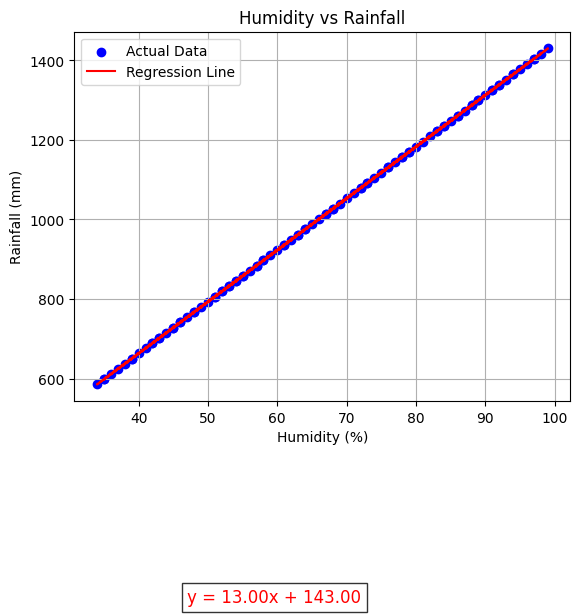

In [61]:
# Plot
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, model.predict(X), color="red", label="Regression Line")

plt.text( 47, 38, f"y = {m:.2f}x + {c:.2f}", fontsize=12, color="red",bbox=dict(facecolor="white", alpha=0.8))
plt.xlabel("Humidity (%)")
plt.ylabel("Rainfall (mm)")
plt.title("Humidity vs Rainfall")
plt.legend(loc='best')
plt.grid(True)
plt.show()